# Selective prediction across KS, Burgers, T2M and the UCI datasets

Loads the per-example arrays written by `evaluation/selective_prediction.py` and compares
two models on every dataset:

* **normal** -- our distributional diffusion, whose EU is the predicted noise *variance*
  accumulated over the reverse trajectory;
* **ensemble** -- the deterministic diffusion aggregated over several training
  checkpoints, whose EU is the disagreement (variance) between the member means.

Both models report AU and EU as variances on the same scale, so `tu = au + eu` is
meaningful and the two models' decompositions are directly comparable.

It reports the prediction-rejection ratio (PRR) for total / aleatoric / epistemic
uncertainty for both models, the correlation between their AU and EU, and draws the
retention curves side by side.

Generate the inputs first, e.g.

```bash
python evaluation/selective_prediction.py --datasets KS,Burgers,T2M
python evaluation/selective_prediction.py --datasets UCI_concrete,UCI_energy
```

The script only evaluates and saves `.npz` files -- every figure, including the
per-dataset retention curve it used to write itself, is drawn here. It has to run on a
compute node, and there matplotlib's usetex backend (which the `scienceplots` style turns
on) has no complete texmf tree, so any `savefig` aborts the run.

T2M has only one deterministic checkpoint, so it has no ensemble and appears with the
distributional model only.

Every ensemble is five deterministic checkpoints trained with seeds 1-5 on the same data
as the distributional model -- for UCI that is Yarin-Gal split 0 (checkpoints under
`results/selective_prediction/UCI/<dataset>`, trained from `config/CARD_single_split`), so
the test set is held out from all five members and neither model has seen it.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sys.path.insert(0, str(Path.cwd()))

# Reuse the retention/PRR definitions from the script so the two never drift apart.
import selective_prediction as sp

RESULTS_DIR = Path("../results/selective_prediction")
PLOTS_DIR = Path("plots")

# Every dataset the script knows about, so the two never drift apart either.
DATASETS = list(sp.DATASETS)
MODELS = list(sp.MODEL_KINDS)

# Only the field datasets go into the paper's retention-curve figure; the UCI
# results are reported in the tables.
PANEL_DATASETS = ["KS", "Burgers", "T2M"]

# EU reduction variant to load: "" is the default (mean over all diffusion steps),
# other runs are suffixed e.g. "_max" or "_last5". The suffix applies to the
# distributional model only -- the ensemble EU has no diffusion-step axis.
VARIANT = ""

MEASURES = ["Total uncertainty", "Aleatoric uncertainty", "Epistemic uncertainty"]
MODEL_LABELS = {"normal": "Distributional", "ensemble": "Ensemble"}

# Column names for the tables. Every one of these holds a PRR, so the header says
# so -- the values are otherwise easy to mistake for the uncertainties themselves.
SHORT_MEASURES = {m: m.split()[0] for m in MEASURES}
PRR_COLUMNS = {m: f"PRR {short}" for m, short in SHORT_MEASURES.items()}
MODEL_ORDER = [MODEL_LABELS[m] for m in MODELS]


# All plotting lives here rather than in the script: the script runs on a compute
# node, where the scienceplots style turns on matplotlib's usetex backend and the
# incomplete texmf tree there makes every savefig fail.
def use_paper_style():
    try:
        import scienceplots  # noqa: F401

        plt.style.use(["science", "grid"])
    except (ImportError, OSError):
        plt.style.use("seaborn-v0_8-whitegrid")


def measure_colors():
    try:
        from cmap import Colormap

        palette = Colormap("colorbrewer:set1_5")
        return [palette(i / 4) for i in range(5)]
    except ImportError:
        return ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00"]

## Load results

In [2]:
# results is keyed by (dataset, model). Missing files are reported and skipped, so
# the notebook still runs after a partial sweep.
results = {}
for name in DATASETS:
    for model in MODELS:
        # The EU-reduction suffix only exists for the distributional model.
        suffix = VARIANT if model == "normal" else ""
        path = RESULTS_DIR / f"{name}_{model}{suffix}.npz"
        if not path.exists():
            print(f"[{name}/{model}] missing {path.name} -- run selective_prediction.py for it.")
            continue
        with np.load(path, allow_pickle=True) as f:
            results[(name, model)] = {k: f[k] for k in f.files}
        r = results[(name, model)]
        print(
            f"[{name}/{model}] n={len(r['mse'])}  n_ensemble={r['n_ensemble']}  "
            f"mse={r['mse'].mean():.3e}  ckpt={r['checkpoint']}"
        )

[KS/normal] n=1000  n_ensemble=100  mse=2.224e-06  ckpt=Datetime_20250831_102648_Loss_1D_KS_UNet_diffusion_normal_T50_DDIM1.pt
[KS/ensemble] n=1000  n_ensemble=100  mse=2.469e-06  ckpt=Datetime_20250902_080935_Loss_1D_KS_UNet_diffusion_deterministic_T50_DDIM1.pt
[Burgers/normal] n=1000  n_ensemble=100  mse=3.844e-06  ckpt=Datetime_20250829_011108_Loss_1D_Burgers_UNet_diffusion_normal_T50_DDIM1.pt
[Burgers/ensemble] n=1000  n_ensemble=100  mse=4.626e-06  ckpt=Datetime_20250901_152520_Loss_1D_Burgers_UNet_diffusion_deterministic_T50_DDIM1.pt
[T2M/normal] n=729  n_ensemble=100  mse=6.118e-03  ckpt=Datetime_20250908_031720_Loss_WeatherBench_UNet_diffusion_normal_T50_DDIM1.pt
[T2M/ensemble] missing T2M_ensemble.npz -- run selective_prediction.py for it.
[UCI_concrete/normal] n=103  n_ensemble=100  mse=7.260e-02  ckpt=Datetime_20260414_161517_Loss_concrete0_MLP_diffusion_normal_T50_DDIM1.pt
[UCI_concrete/ensemble] n=103  n_ensemble=100  mse=7.335e-02  ckpt=Datetime_20260724_115457_Loss_concr

In [3]:
# Retention curves + baselines for every (dataset, model) pair.
curves_by_key = {}
for key, r in results.items():
    grid = r["retention_grid"]
    curves, oracle, random_curve = sp.build_curves(r["au"], r["eu"], r["mse"], grid)
    curves_by_key[key] = dict(
        grid=grid, curves=curves, oracle=oracle, random=random_curve
    )

## PRR table

PRR is the area between the retention curve and the random baseline, normalised by the
area between the oracle and random baselines, over retention in [0.5, 1].
**1** means the uncertainty ranks examples as well as the realised error itself,
**0** means it is no better than rejecting at random, and negative values mean it is worse.

In [4]:
rows = []
for (name, model), c in curves_by_key.items():
    row = {
        "Dataset": name,
        "Model": MODEL_LABELS[model],
        "n": len(results[(name, model)]["mse"]),
        "MSE": results[(name, model)]["mse"].mean(),
    }
    for measure, column in PRR_COLUMNS.items():
        row[column] = sp.prediction_rejection_ratio(
            c["curves"][measure], c["oracle"], c["random"], c["grid"]
        )
    rows.append(row)

prr_table = pd.DataFrame(rows).set_index(["Dataset", "Model"])
prr_table.style.format(
    {"MSE": "{:.3e}", **{c: "{:.4f}" for c in PRR_COLUMNS.values()}}
)

In [5]:
# LaTeX version, matching the other result tables under results/.
# The caption carries "PRR", so the columns drop the prefix to stay narrow.
# MSE is formatted separately: at 1e-06 a plain %.4f would round it to 0.0000.
latex_table = prr_table.rename(
    columns={c: c.removeprefix("PRR ") for c in PRR_COLUMNS.values()}
).copy()
latex_table["MSE"] = latex_table["MSE"].map("{:.2e}".format)

print(
    latex_table.to_latex(
        float_format="%.4f",
        caption="PRR by dataset, model and uncertainty measure.",
    )
)

\begin{table}
\caption{PRR by dataset, model and uncertainty measure.}
\begin{tabular}{llrlrrr}
\toprule
 &  & n & MSE & Total & Aleatoric & Epistemic \\
Dataset & Model &  &  &  &  &  \\
\midrule
\multirow[t]{2}{*}{KS} & Distributional & 1000 & 2.22e-06 & 0.8402 & 0.8394 & 0.8453 \\
 & Ensemble & 1000 & 2.47e-06 & 0.7937 & 0.6881 & 0.8177 \\
\cline{1-7}
\multirow[t]{2}{*}{Burgers} & Distributional & 1000 & 3.84e-06 & 0.9945 & 0.9945 & 0.9945 \\
 & Ensemble & 1000 & 4.63e-06 & 0.9921 & 0.9899 & 0.9942 \\
\cline{1-7}
T2M & Distributional & 729 & 6.12e-03 & 0.7286 & 0.7286 & 0.6951 \\
\cline{1-7}
\multirow[t]{2}{*}{UCI_concrete} & Distributional & 103 & 7.26e-02 & 0.3953 & 0.3903 & 0.3803 \\
 & Ensemble & 103 & 7.34e-02 & 0.2198 & 0.2197 & 0.0939 \\
\cline{1-7}
\multirow[t]{2}{*}{UCI_energy} & Distributional & 77 & 1.22e-03 & 0.4986 & 0.5015 & 0.4161 \\
 & Ensemble & 77 & 1.17e-03 & 0.0820 & 0.2224 & 0.0420 \\
\cline{1-7}
\multirow[t]{2}{*}{UCI_kin8nm} & Distributional & 819 & 6.92e-02 &

### PRR side by side: distributional vs. ensemble

The same PRR numbers as above, with the two models as columns instead of as stacked rows,
so each dataset is one line and the two can be read off against each other directly.
`n` and MSE are dropped here -- they are in the table above.

T2M has no ensemble, so its ensemble columns are empty.

In [6]:
# Pivot Model out of the row index and into the columns, giving a
# (Model, Measure) column MultiIndex: Distributional | Ensemble, each with
# Total / Aleatoric / Epistemic.
prr_by_model = (
    prr_table[list(PRR_COLUMNS.values())]
    .rename(columns={c: c.removeprefix("PRR ") for c in PRR_COLUMNS.values()})
    .unstack("Model")
    .swaplevel(axis=1)
)

# unstack sorts both axes alphabetically; restore the declared orders so Total
# comes before Aleatoric and the datasets stay in the script's order.
prr_by_model = prr_by_model.reindex(
    index=[d for d in DATASETS if d in prr_by_model.index],
    columns=pd.MultiIndex.from_product([MODEL_ORDER, list(SHORT_MEASURES.values())]),
)

prr_by_model.style.format("{:.4f}", na_rep="--")

In [7]:
# LaTeX version of the side-by-side PRR table.
print(
    prr_by_model.to_latex(
        float_format="%.4f",
        na_rep="--",
        multicolumn_format="c",
        caption="PRR per dataset for the distributional model and the deep ensemble.",
    )
)

\begin{table}
\caption{PRR per dataset for the distributional model and the deep ensemble.}
\begin{tabular}{lrrrrrr}
\toprule
 & \multicolumn{3}{c}{Distributional} & \multicolumn{3}{c}{Ensemble} \\
 & Total & Aleatoric & Epistemic & Total & Aleatoric & Epistemic \\
Dataset &  &  &  &  &  &  \\
\midrule
KS & 0.8402 & 0.8394 & 0.8453 & 0.7937 & 0.6881 & 0.8177 \\
Burgers & 0.9945 & 0.9945 & 0.9945 & 0.9921 & 0.9899 & 0.9942 \\
T2M & 0.7286 & 0.7286 & 0.6951 & -- & -- & -- \\
UCI_concrete & 0.3953 & 0.3903 & 0.3803 & 0.2198 & 0.2197 & 0.0939 \\
UCI_energy & 0.4986 & 0.5015 & 0.4161 & 0.0820 & 0.2224 & 0.0420 \\
UCI_kin8nm & 0.2083 & 0.2072 & 0.2500 & 0.2526 & 0.2629 & 0.0259 \\
UCI_naval & 0.7895 & 0.7877 & 0.7709 & 0.5707 & 0.7382 & 0.1661 \\
UCI_power & 0.2213 & 0.2210 & 0.2066 & 0.1661 & 0.1593 & 0.0628 \\
UCI_protein & 0.4283 & 0.4284 & 0.3517 & 0.4396 & 0.4363 & 0.3428 \\
UCI_wine & 0.0273 & 0.0250 & 0.1002 & 0.0953 & -0.0117 & 0.1794 \\
UCI_yacht & 0.9334 & 0.9296 & 0.9527 & 0.9424 

## Correlation between our uncertainties and the ensemble's

How closely does the distributional model's decomposition track the deep ensemble's on
the *same* test examples? For each dataset the table pairs our AU against the ensemble's
AU, our EU against its EU, and likewise for TU.

Two coefficients per pair:

* **Pearson** -- linear agreement of the raw magnitudes. Both models now report
  variances, so the two are on a comparable scale, but ours is a noise variance
  propagated through the reverse trajectory while the ensemble's is a variance between
  checkpoints -- there is no reason for the constant relating them to be 1, and Pearson
  penalises that.
* **Spearman** -- rank agreement. This is the one that matters for selective prediction:
  the retention curves only ever use the *ordering* of the examples, so two measures with
  Spearman 1 would reject exactly the same examples and score the same PRR regardless of
  how differently they are scaled.

Both runs must have been produced with the same `--seed` and `--n-samples`, since the
PDE test sets draw a random timestep per example. The `target_mean` fingerprint saved by
the script is checked below, so a mismatch is caught rather than silently correlating
uncertainties from different examples.

In [8]:
# AU/EU/TU of our distributional model vs. the deterministic-diffusion ensemble.
PAIRS = [("au", "AU"), ("eu", "EU"), ("tu", "TU")]


def same_examples(a, b):
    """True if two runs evaluated the same test examples, in the same order.

    ``target_mean`` is the per-example domain mean of the target, which does not
    depend on the model -- so it identifies the example without needing an index.
    Older result files predate the fingerprint; those fall back to a length check.
    """
    if "target_mean" not in a or "target_mean" not in b:
        return len(a["mse"]) == len(b["mse"])
    return a["target_mean"].shape == b["target_mean"].shape and np.allclose(
        a["target_mean"], b["target_mean"], rtol=0, atol=1e-6
    )


rows = []
for name in DATASETS:
    ours = results.get((name, "normal"))
    ens = results.get((name, "ensemble"))
    if ours is None or ens is None:
        continue
    if not same_examples(ours, ens):
        print(
            f"[{name}] the two runs did not evaluate the same examples -- "
            "re-run both with the same --seed and --n-samples. Skipped."
        )
        continue

    row = {"Dataset": name, "n": len(ours["mse"])}
    for key, label in PAIRS:
        row[f"{label} Pearson"] = pearsonr(ours[key], ens[key])[0]
        row[f"{label} Spearman"] = spearmanr(ours[key], ens[key])[0]
    rows.append(row)

corr_table = pd.DataFrame(rows).set_index("Dataset")
corr_table.style.format({c: "{:.4f}" for c in corr_table.columns if c != "n"})

,n,AU Pearson,AU Spearman,EU Pearson,EU Spearman,TU Pearson,TU Spearman
Dataset,,,,,,,
KS,1000,0.9331,0.9640,0.8339,0.8210,0.9468,0.9207
Burgers,1000,0.8430,0.8185,0.6482,0.8899,0.7902,0.8839
UCI_concrete,103,0.7552,0.8100,0.1601,0.1510,0.7072,0.7601
UCI_energy,77,0.4886,0.7664,0.6053,0.5723,0.6098,0.6671
UCI_kin8nm,819,0.8250,0.8279,0.4128,0.3899,0.8236,0.8310
UCI_naval,1193,0.7938,0.6804,0.1830,0.5669,0.4717,0.7024
UCI_power,957,0.4457,0.5618,0.1233,0.1596,0.4316,0.5360
UCI_protein,4573,0.8241,0.8542,0.4128,0.6630,0.8204,0.8537
UCI_wine,160,0.4282,0.4551,0.0842,0.3649,0.4103,0.4118


In [9]:
# LaTeX version of the correlation table.
print(
    corr_table.to_latex(
        float_format="%.3f",
        caption="Correlation between the distributional model's and the deep "
        "ensemble's uncertainty decompositions, per test example.",
    )
)

\begin{table}
\caption{Correlation between the distributional model's and the deep ensemble's uncertainty decompositions, per test example.}
\begin{tabular}{lrrrrrrr}
\toprule
 & n & AU Pearson & AU Spearman & EU Pearson & EU Spearman & TU Pearson & TU Spearman \\
Dataset &  &  &  &  &  &  &  \\
\midrule
KS & 1000 & 0.933 & 0.964 & 0.834 & 0.821 & 0.947 & 0.921 \\
Burgers & 1000 & 0.843 & 0.818 & 0.648 & 0.890 & 0.790 & 0.884 \\
UCI_concrete & 103 & 0.755 & 0.810 & 0.160 & 0.151 & 0.707 & 0.760 \\
UCI_energy & 77 & 0.489 & 0.766 & 0.605 & 0.572 & 0.610 & 0.667 \\
UCI_kin8nm & 819 & 0.825 & 0.828 & 0.413 & 0.390 & 0.824 & 0.831 \\
UCI_naval & 1193 & 0.794 & 0.680 & 0.183 & 0.567 & 0.472 & 0.702 \\
UCI_power & 957 & 0.446 & 0.562 & 0.123 & 0.160 & 0.432 & 0.536 \\
UCI_protein & 4573 & 0.824 & 0.854 & 0.413 & 0.663 & 0.820 & 0.854 \\
UCI_wine & 160 & 0.428 & 0.455 & 0.084 & 0.365 & 0.410 & 0.412 \\
UCI_yacht & 31 & 0.646 & 0.700 & 0.724 & 0.725 & 0.820 & 0.796 \\
\bottomrule
\end{tabular}

### EU rank agreement across all datasets

Spearman only, EU only, one bar per dataset: how well our epistemic uncertainty
reproduces the deep ensemble's *ordering* of the test examples. The ordering is the only
thing selective prediction depends on, so this is the summary view of whether the two
notions of epistemic uncertainty agree.

Every ensemble here is held out from the test set it is evaluated on, so the bars are
comparable across datasets.

saved plots/eu_spearman_by_dataset.pdf


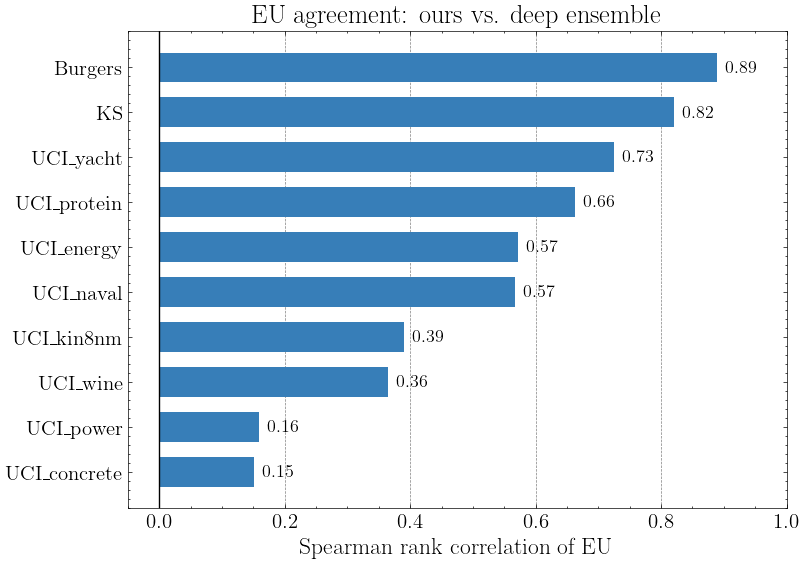

In [10]:
# Horizontal bars: one measure (EU Spearman) across datasets, sorted, so the
# comparison is a length comparison rather than a scan across a wide table.
use_paper_style()
palette = measure_colors()
# One colour throughout: all ensembles are now held out from their test sets, so
# there is no second category to encode.
BAR_COLOR = palette[1]

eu_spearman = corr_table["EU Spearman"].sort_values()

ticksize, axissize, titlesize, labelsize = 15, 17, 19, 13

lo = min(0.0, eu_spearman.min()) - 0.05
hi = max(1.0, eu_spearman.max() + 0.05)
pad = 0.012 * (hi - lo)

fig, ax = plt.subplots(figsize=(8.5, 0.46 * len(eu_spearman) + 1.6))
ypos = np.arange(len(eu_spearman))
ax.barh(ypos, eu_spearman.values, height=0.66, color=BAR_COLOR)

# Direct labels on every bar: with ten of them the values are the point of the
# figure, and they double as the readable channel for the lighter fill.
for y, v in zip(ypos, eu_spearman.values):
    ax.text(
        v + (pad if v >= 0 else -pad),
        y,
        f"{v:.2f}",
        va="center",
        ha="left" if v >= 0 else "right",
        fontsize=labelsize,
    )

if lo < 0:
    ax.axvline(0, color="black", lw=1.0)

ax.set_yticks(ypos)
ax.set_yticklabels(eu_spearman.index)
ax.set_xlim(lo, hi)
ax.set_xlabel("Spearman rank correlation of EU", fontsize=axissize)
ax.set_title("EU agreement: ours vs. deep ensemble", fontsize=titlesize)
ax.tick_params(axis="both", which="major", labelsize=ticksize)
ax.grid(axis="y", visible=False)

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
out_path = PLOTS_DIR / f"eu_spearman_by_dataset{VARIANT}.pdf"
fig.savefig(out_path, bbox_inches="tight")
print(f"saved {out_path}")

## Retention curves

One panel per dataset in `PANEL_DATASETS`, for the model selected in `PANEL_MODEL`. Each
panel keeps its own y-scale, since the MSE magnitudes differ by orders of magnitude
between the datasets.

In [11]:
PANEL_DATASETS = ["KS", "Burgers", "T2M"]

saved plots/selective_prediction_panels.pdf


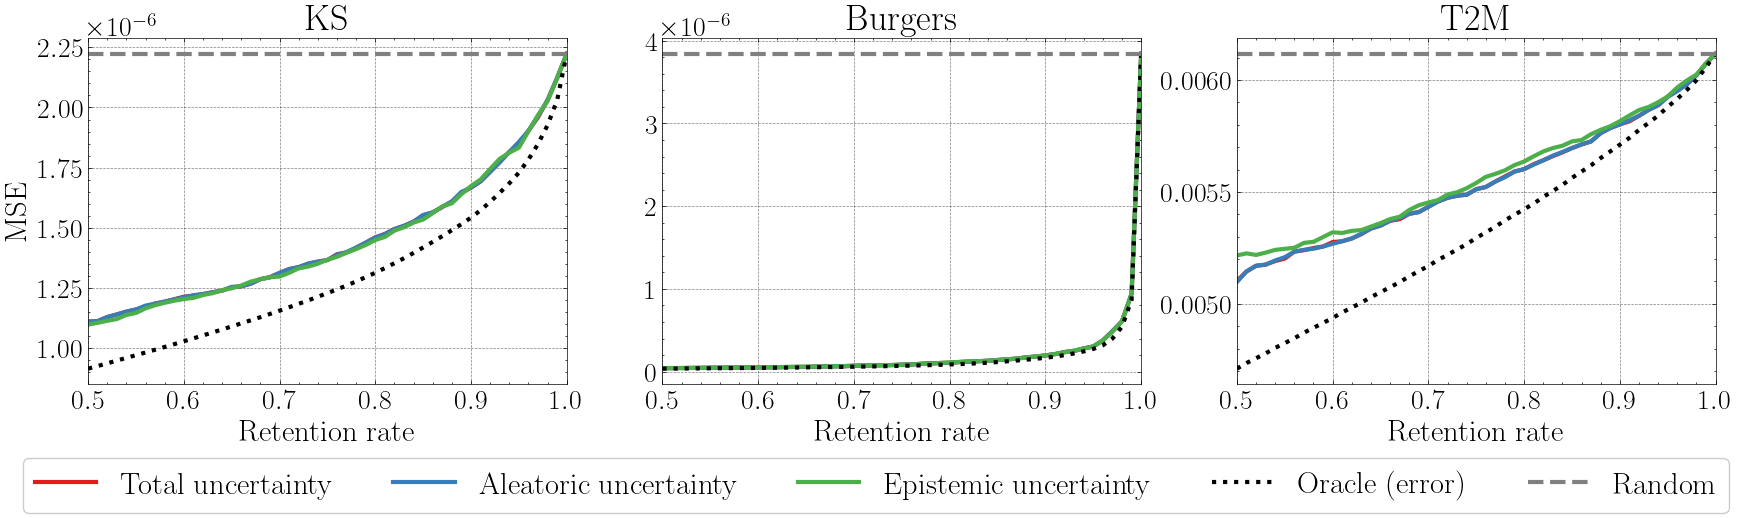

In [12]:
PANEL_MODEL = "normal"

use_paper_style()
colors = measure_colors()

ticksize, axissize, legendsize, titlesize = 20, 22, 22, 26
lw = 3.0

names = [n for n in PANEL_DATASETS if (n, PANEL_MODEL) in curves_by_key]
fig, axs = plt.subplots(1, len(names), figsize=(7 * len(names), 4.5))
axs = np.atleast_1d(axs)

for ax, name in zip(axs, names):
    c = curves_by_key[(name, PANEL_MODEL)]
    grid = c["grid"]
    for (label, curve), color in zip(c["curves"].items(), colors):
        ax.plot(grid, curve, color=color, lw=lw, label=label)
    ax.plot(grid, c["oracle"], color="black", lw=lw, ls=":", label="Oracle (error)")
    ax.plot(grid, c["random"], color="grey", lw=lw, ls="--", label="Random")

    ax.set_title(name, fontsize=titlesize)
    ax.set_xlabel("Retention rate", fontsize=axissize)
    ax.set_xlim(grid[0], grid[-1])
    ax.tick_params(axis="both", which="major", labelsize=ticksize)
    ax.yaxis.get_offset_text().set_fontsize(ticksize)

axs[0].set_ylabel("MSE", fontsize=axissize)

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    bbox_to_anchor=(0.5, -0.02),
    loc="upper center",
    fontsize=legendsize,
    ncol=5,
    frameon=True,
)

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
tag = "" if PANEL_MODEL == "normal" else f"_{PANEL_MODEL}"
out_path = PLOTS_DIR / f"selective_prediction_panels{tag}{VARIANT}.pdf"
fig.savefig(out_path, bbox_inches="tight")
print(f"saved {out_path}")

saved plots/selective_prediction_panels_ensemble.pdf


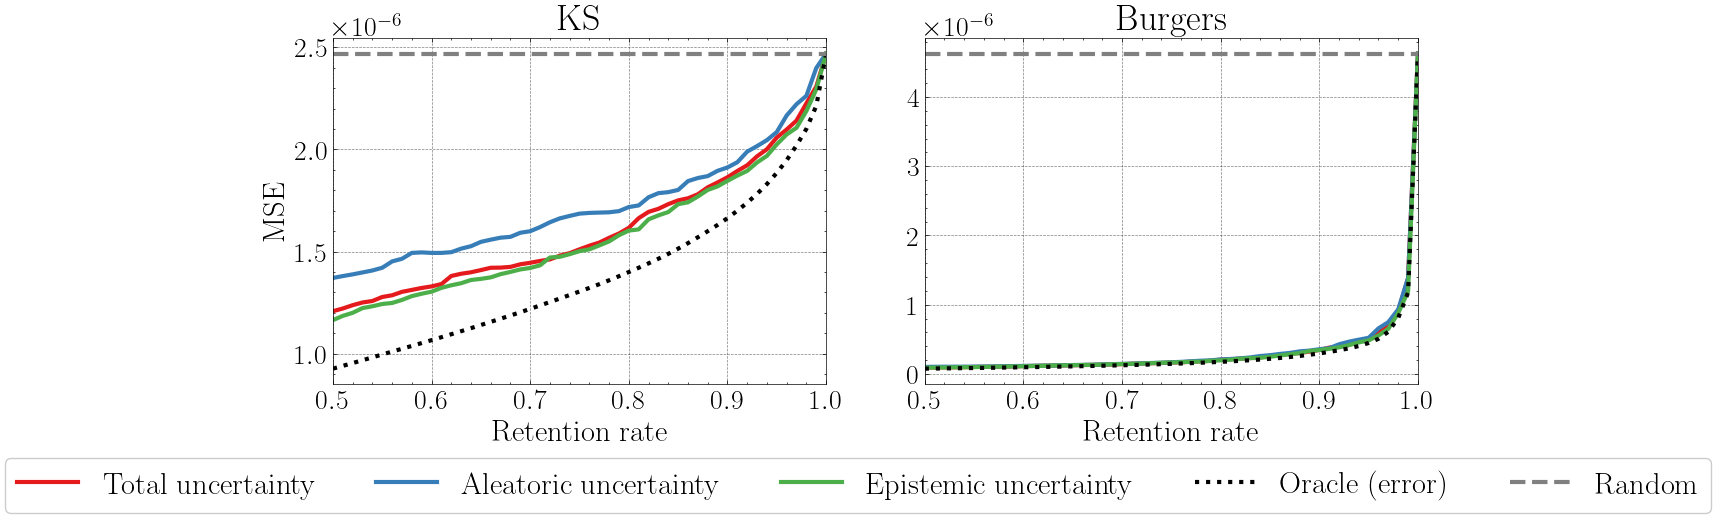

In [13]:
PANEL_MODEL = "ensemble"

use_paper_style()
colors = measure_colors()

ticksize, axissize, legendsize, titlesize = 20, 22, 22, 26
lw = 3.0

names = [n for n in PANEL_DATASETS if (n, PANEL_MODEL) in curves_by_key]
fig, axs = plt.subplots(1, len(names), figsize=(7 * len(names), 4.5))
axs = np.atleast_1d(axs)

for ax, name in zip(axs, names):
    c = curves_by_key[(name, PANEL_MODEL)]
    grid = c["grid"]
    for (label, curve), color in zip(c["curves"].items(), colors):
        ax.plot(grid, curve, color=color, lw=lw, label=label)
    ax.plot(grid, c["oracle"], color="black", lw=lw, ls=":", label="Oracle (error)")
    ax.plot(grid, c["random"], color="grey", lw=lw, ls="--", label="Random")

    ax.set_title(name, fontsize=titlesize)
    ax.set_xlabel("Retention rate", fontsize=axissize)
    ax.set_xlim(grid[0], grid[-1])
    ax.tick_params(axis="both", which="major", labelsize=ticksize)
    ax.yaxis.get_offset_text().set_fontsize(ticksize)

axs[0].set_ylabel("MSE", fontsize=axissize)

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    bbox_to_anchor=(0.5, -0.02),
    loc="upper center",
    fontsize=legendsize,
    ncol=5,
    frameon=True,
)

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
tag = "" if PANEL_MODEL == "normal" else f"_{PANEL_MODEL}"
out_path = PLOTS_DIR / f"selective_prediction_panels{tag}{VARIANT}.pdf"
fig.savefig(out_path, bbox_inches="tight")
print(f"saved {out_path}")

In [14]:
PANEL_DATASETS = ["UCI_concrete", "UCI_kin8nm", "UCI_energy", "UCI_protein", "UCI_power", "UCI_naval", "UCI_yacht", "UCI_wine"]

saved plots/selective_prediction_panels.pdf


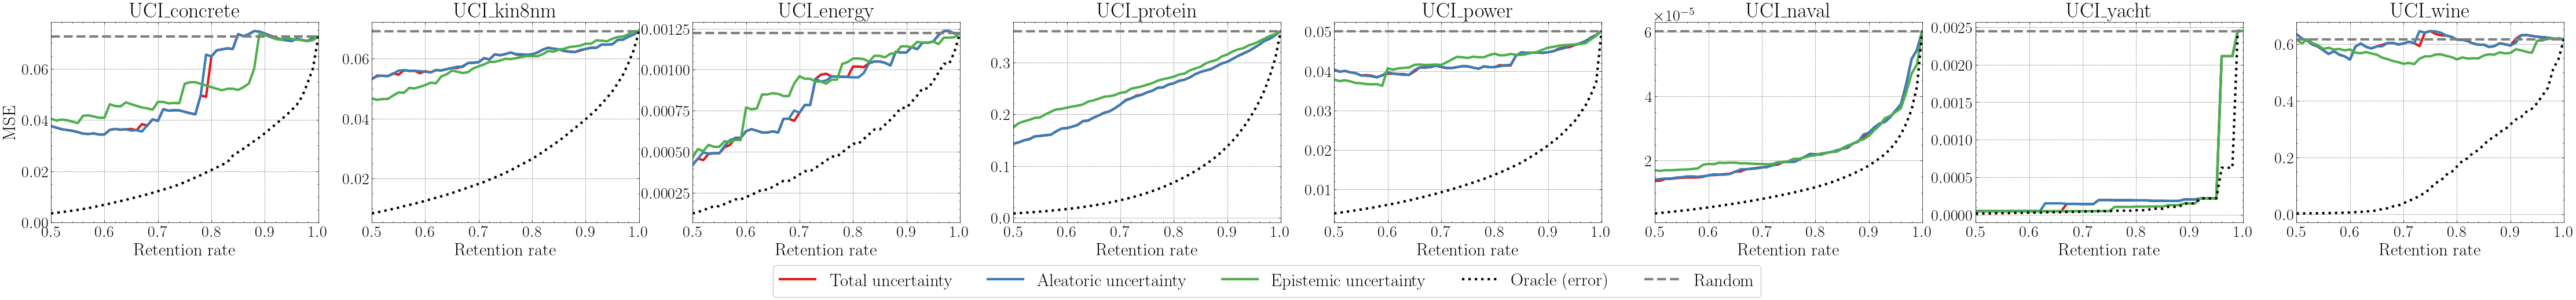

In [15]:
PANEL_MODEL = "normal"

use_paper_style()
colors = measure_colors()

ticksize, axissize, legendsize, titlesize = 20, 22, 22, 26
lw = 3.0

names = [n for n in PANEL_DATASETS if (n, PANEL_MODEL) in curves_by_key]
fig, axs = plt.subplots(1, len(names), figsize=(7 * len(names), 4.5))
axs = np.atleast_1d(axs)

for ax, name in zip(axs, names):
    c = curves_by_key[(name, PANEL_MODEL)]
    grid = c["grid"]
    for (label, curve), color in zip(c["curves"].items(), colors):
        ax.plot(grid, curve, color=color, lw=lw, label=label)
    ax.plot(grid, c["oracle"], color="black", lw=lw, ls=":", label="Oracle (error)")
    ax.plot(grid, c["random"], color="grey", lw=lw, ls="--", label="Random")

    ax.set_title(name, fontsize=titlesize)
    ax.set_xlabel("Retention rate", fontsize=axissize)
    ax.set_xlim(grid[0], grid[-1])
    ax.tick_params(axis="both", which="major", labelsize=ticksize)
    ax.yaxis.get_offset_text().set_fontsize(ticksize)

axs[0].set_ylabel("MSE", fontsize=axissize)

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    bbox_to_anchor=(0.5, -0.02),
    loc="upper center",
    fontsize=legendsize,
    ncol=5,
    frameon=True,
)

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
tag = "" if PANEL_MODEL == "normal" else f"_{PANEL_MODEL}"
out_path = PLOTS_DIR / f"selective_prediction_panels{tag}{VARIANT}.pdf"
fig.savefig(out_path, bbox_inches="tight")
print(f"saved {out_path}")

saved plots/selective_prediction_panels_ensemble.pdf


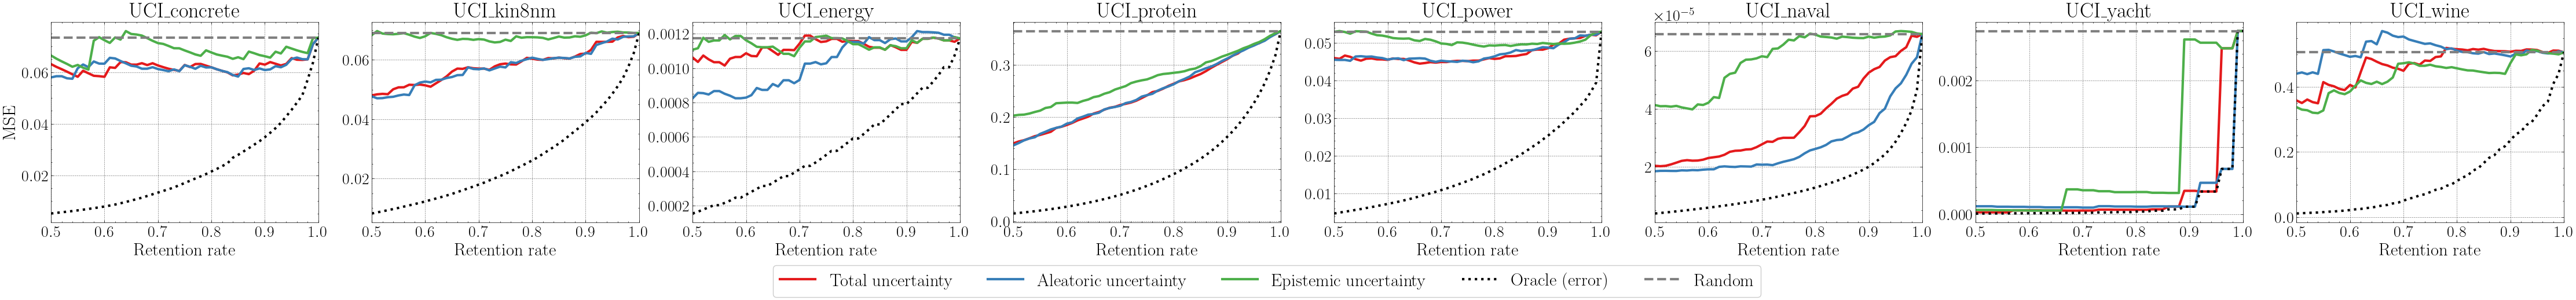

In [16]:
PANEL_MODEL = "ensemble"

use_paper_style()
colors = measure_colors()

ticksize, axissize, legendsize, titlesize = 20, 22, 22, 26
lw = 3.0

names = [n for n in PANEL_DATASETS if (n, PANEL_MODEL) in curves_by_key]
fig, axs = plt.subplots(1, len(names), figsize=(7 * len(names), 4.5))
axs = np.atleast_1d(axs)

for ax, name in zip(axs, names):
    c = curves_by_key[(name, PANEL_MODEL)]
    grid = c["grid"]
    for (label, curve), color in zip(c["curves"].items(), colors):
        ax.plot(grid, curve, color=color, lw=lw, label=label)
    ax.plot(grid, c["oracle"], color="black", lw=lw, ls=":", label="Oracle (error)")
    ax.plot(grid, c["random"], color="grey", lw=lw, ls="--", label="Random")

    ax.set_title(name, fontsize=titlesize)
    ax.set_xlabel("Retention rate", fontsize=axissize)
    ax.set_xlim(grid[0], grid[-1])
    ax.tick_params(axis="both", which="major", labelsize=ticksize)
    ax.yaxis.get_offset_text().set_fontsize(ticksize)

axs[0].set_ylabel("MSE", fontsize=axissize)

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    bbox_to_anchor=(0.5, -0.02),
    loc="upper center",
    fontsize=legendsize,
    ncol=5,
    frameon=True,
)

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
tag = "" if PANEL_MODEL == "normal" else f"_{PANEL_MODEL}"
out_path = PLOTS_DIR / f"selective_prediction_panels{tag}{VARIANT}.pdf"
fig.savefig(out_path, bbox_inches="tight")
print(f"saved {out_path}")

### One figure per dataset and model

The single-panel retention curves that `selective_prediction.py` used to write itself,
under the same names (`<dataset>[_ensemble]_selective_prediction<variant>.pdf`). Drawing
them here instead keeps the script free of matplotlib, which cannot render anything on
the compute nodes.

`SINGLE_FIGURE_DATASETS` selects which datasets get one; set it to `DATASETS` for all of
them, UCI included.

saved plots/UCI_concrete_selective_prediction.pdf
saved plots/UCI_concrete_ensemble_selective_prediction.pdf
saved plots/UCI_energy_selective_prediction.pdf
saved plots/UCI_energy_ensemble_selective_prediction.pdf
saved plots/UCI_kin8nm_selective_prediction.pdf
saved plots/UCI_kin8nm_ensemble_selective_prediction.pdf
saved plots/UCI_naval_selective_prediction.pdf
saved plots/UCI_naval_ensemble_selective_prediction.pdf
saved plots/UCI_power_selective_prediction.pdf
saved plots/UCI_power_ensemble_selective_prediction.pdf
saved plots/UCI_protein_selective_prediction.pdf
saved plots/UCI_protein_ensemble_selective_prediction.pdf
saved plots/UCI_wine_selective_prediction.pdf
saved plots/UCI_wine_ensemble_selective_prediction.pdf
saved plots/UCI_yacht_selective_prediction.pdf
saved plots/UCI_yacht_ensemble_selective_prediction.pdf


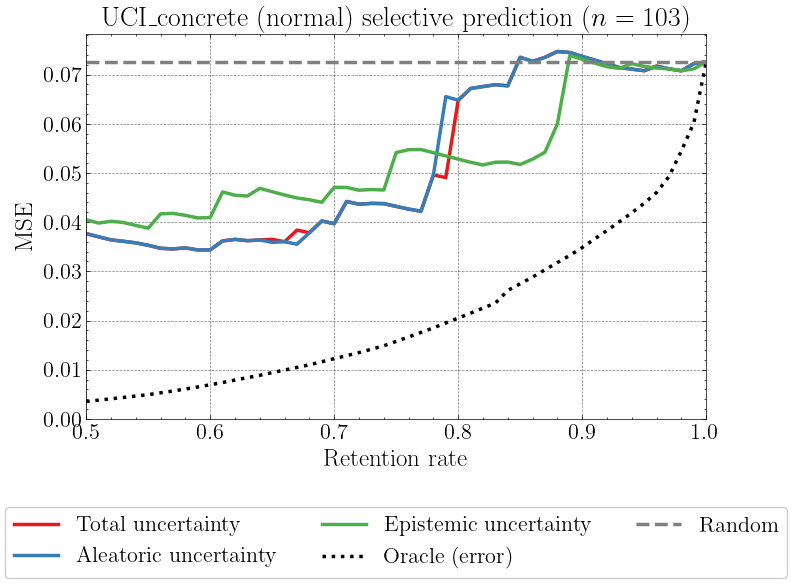

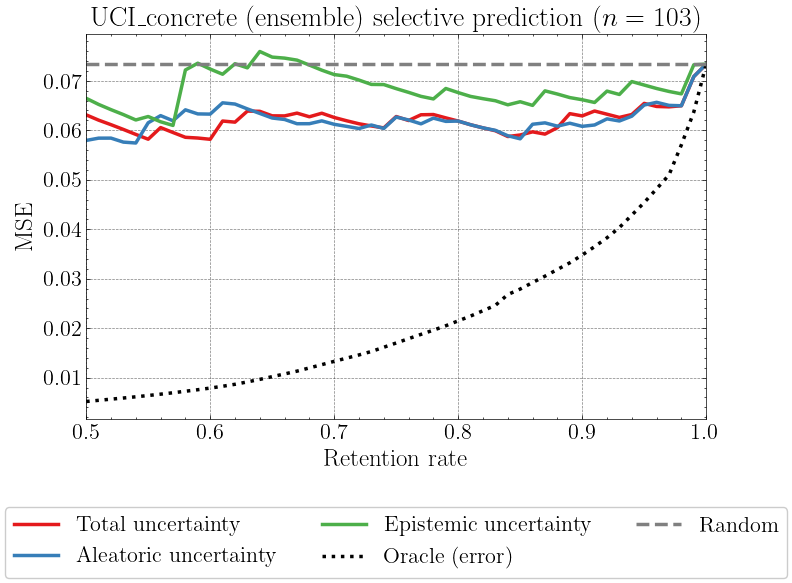

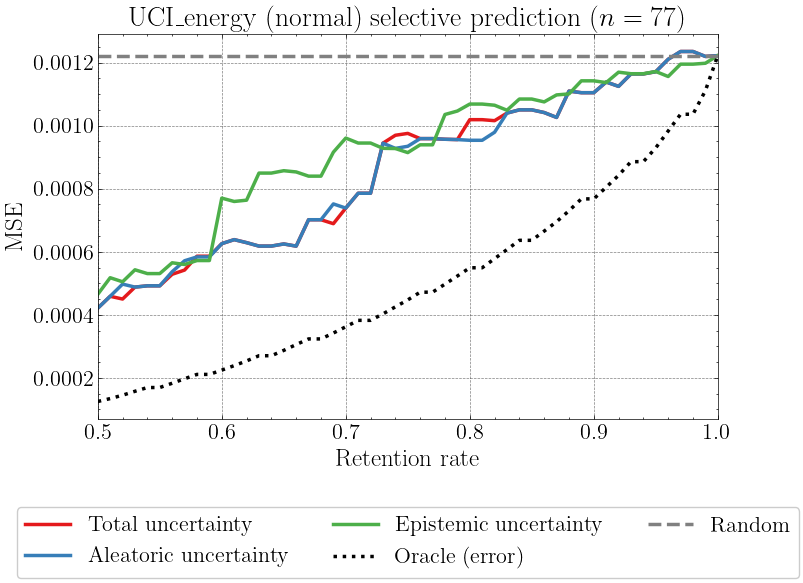

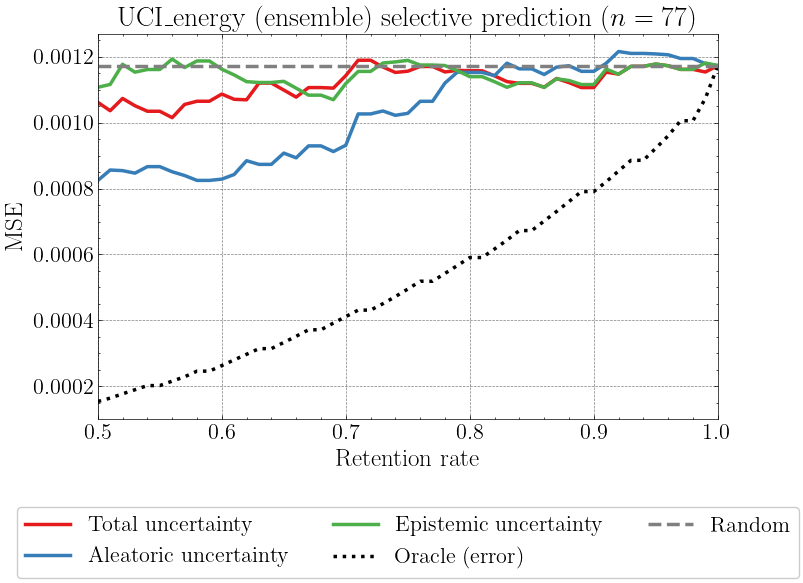

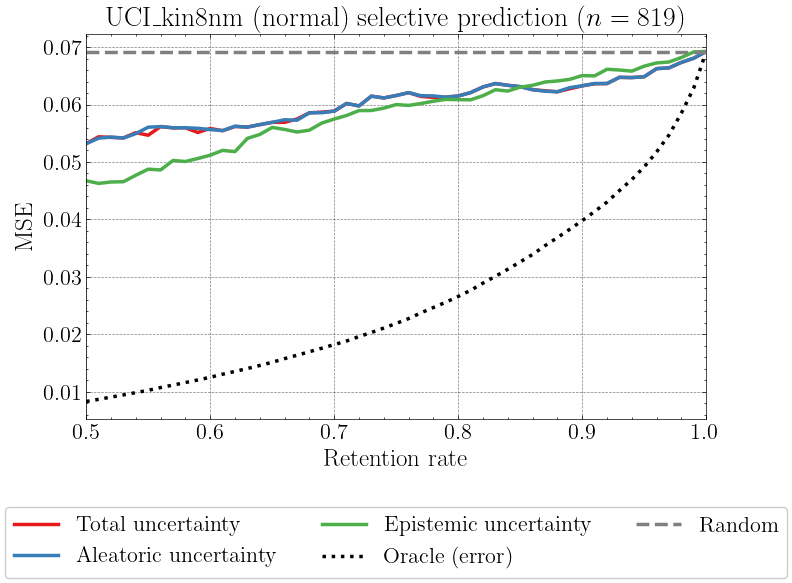

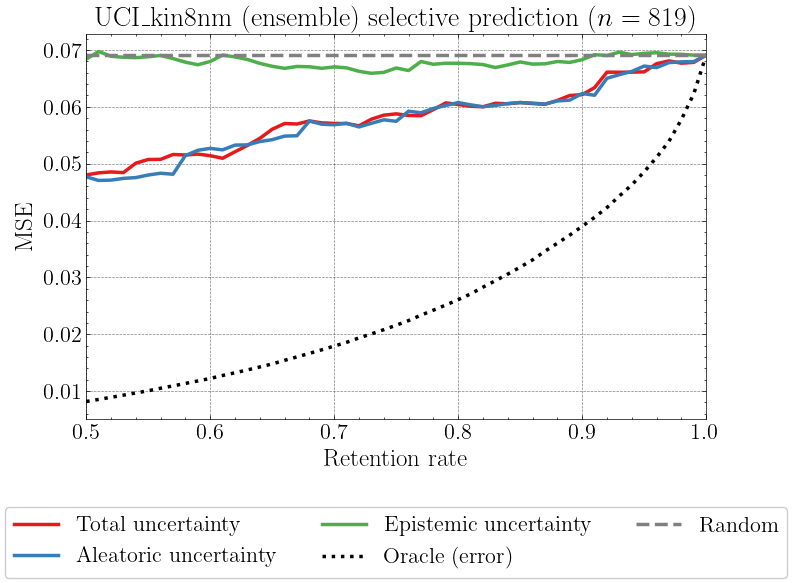

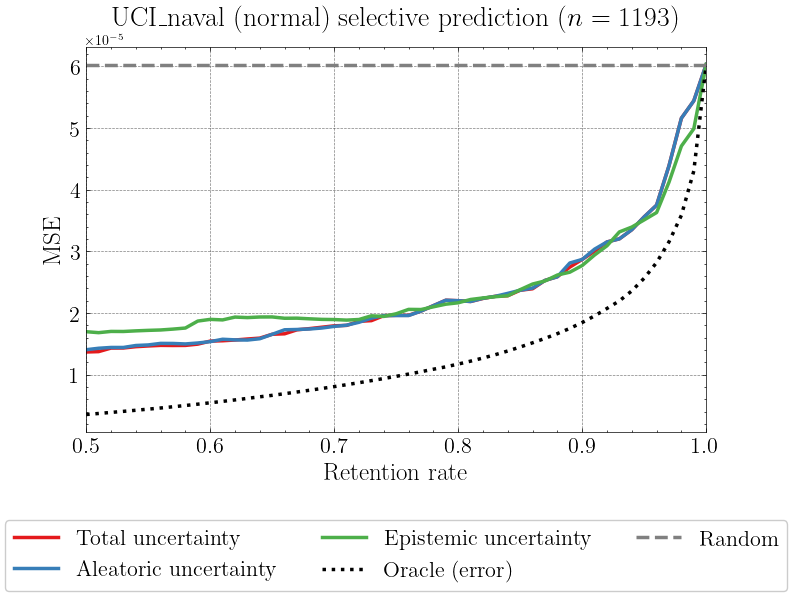

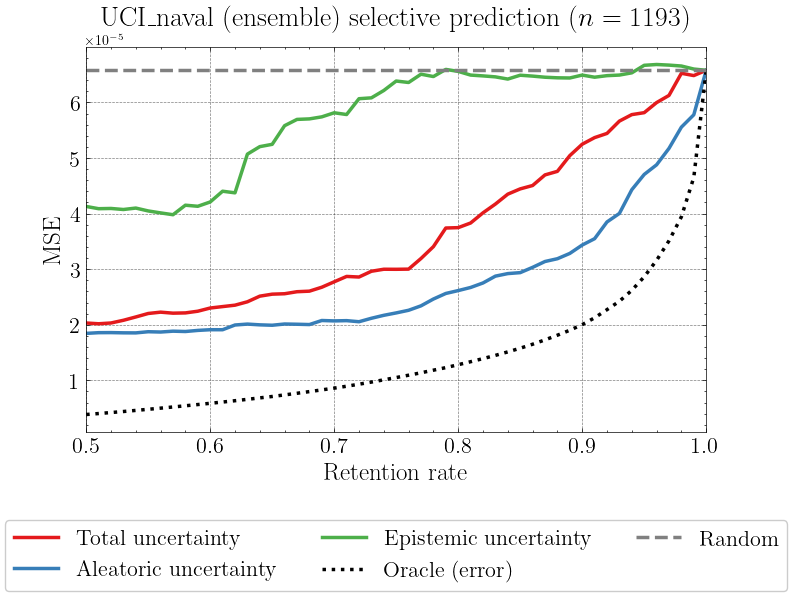

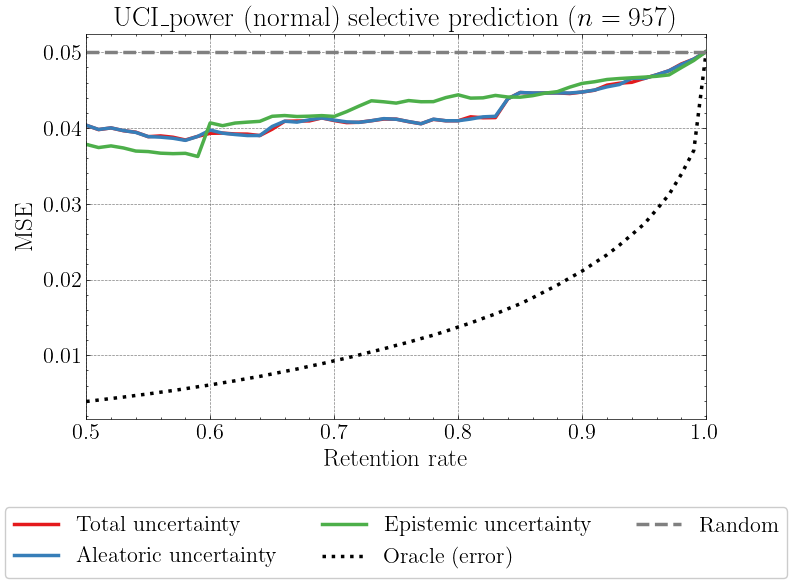

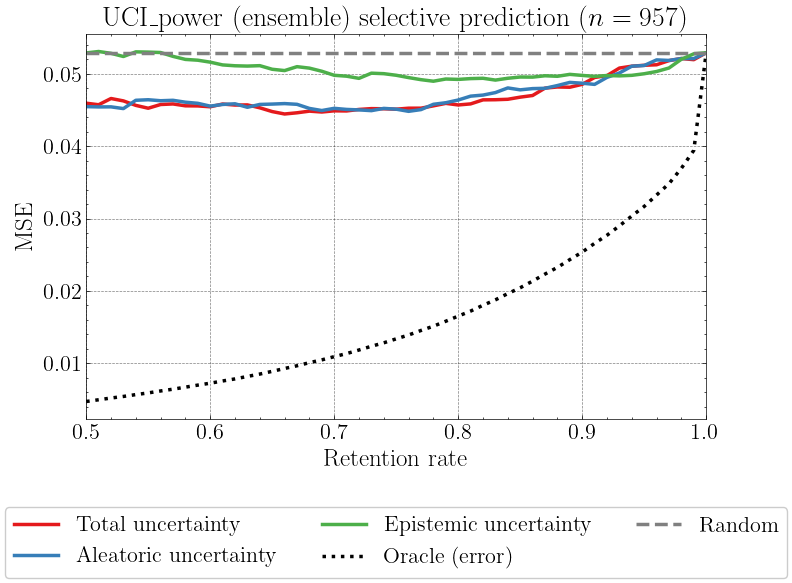

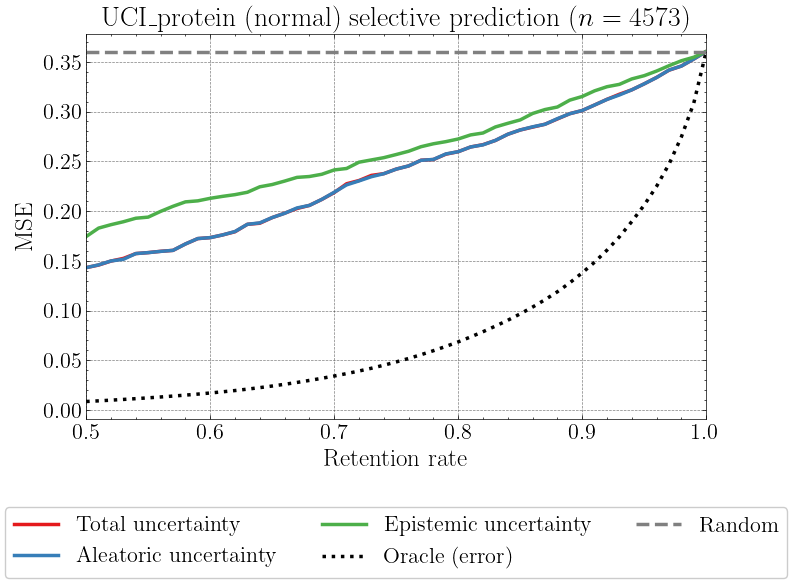

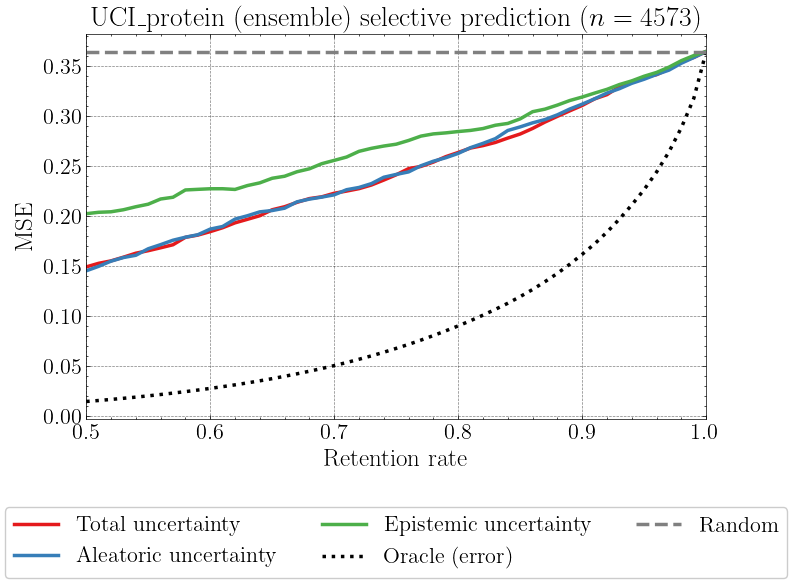

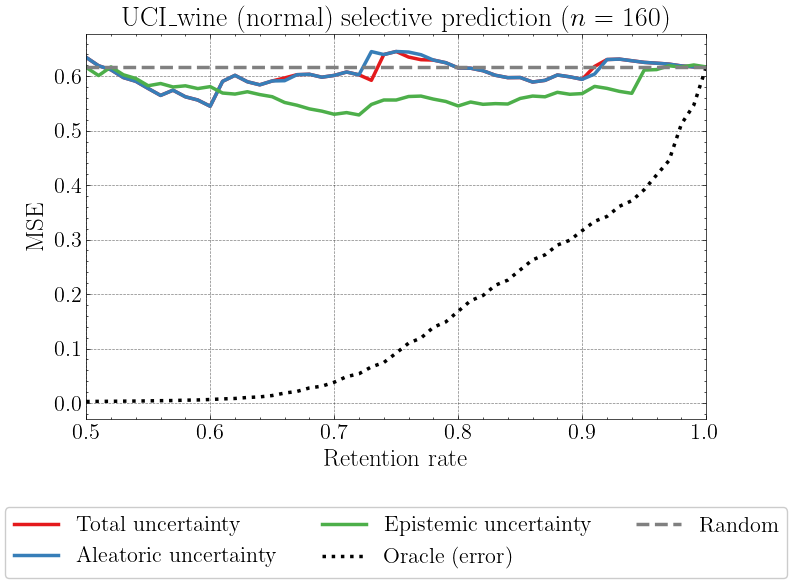

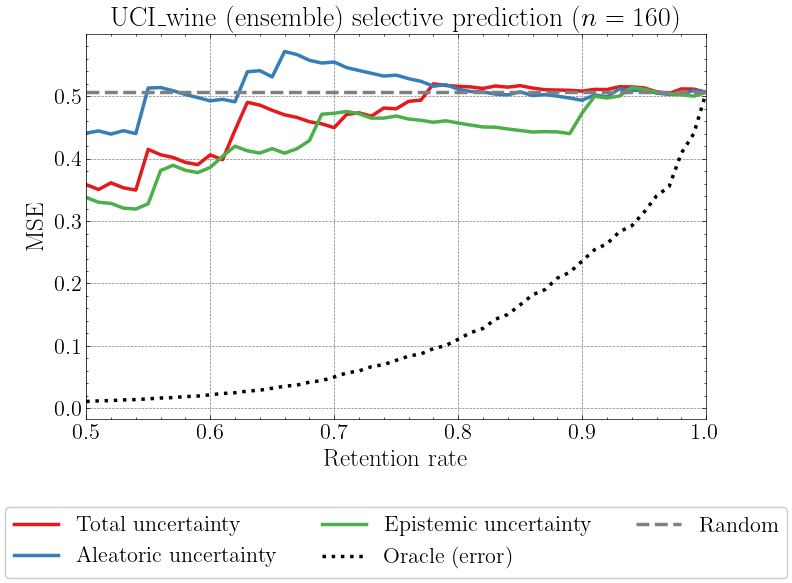

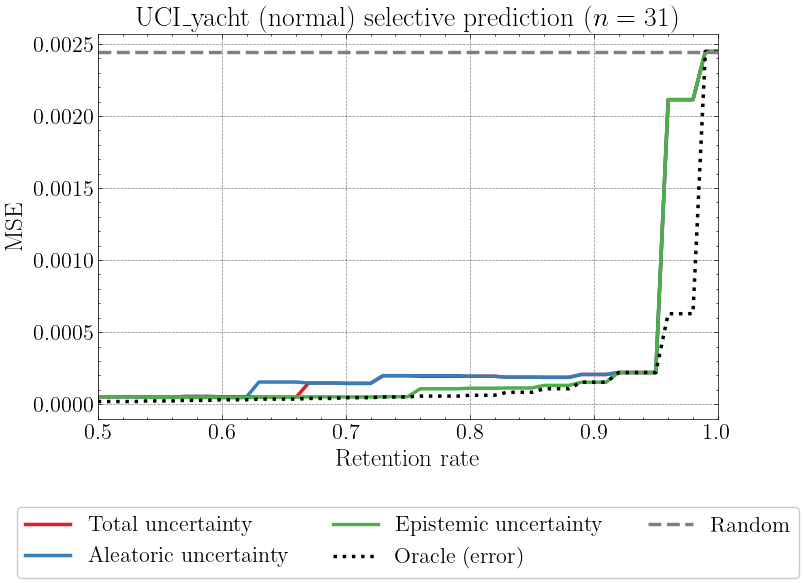

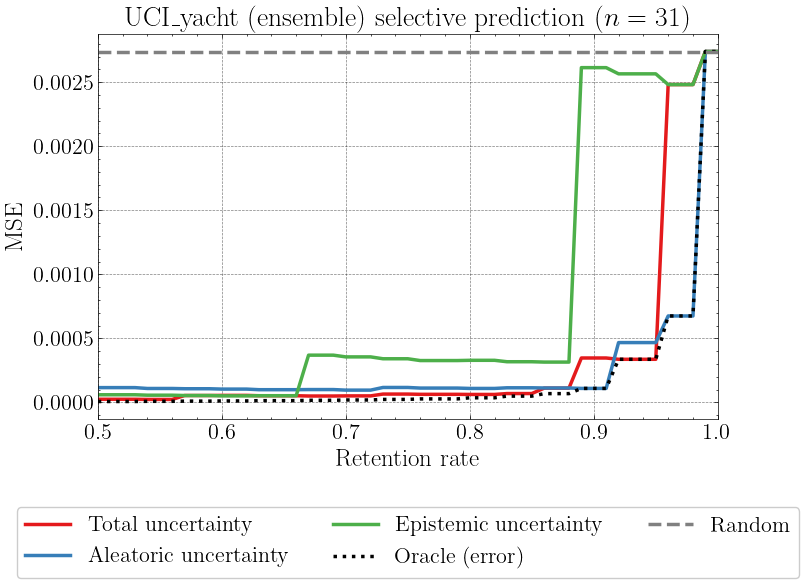

In [17]:
SINGLE_FIGURE_DATASETS = PANEL_DATASETS


def plot_retention(curves, oracle, random_curve, retention_grid, n_used, title):
    """The single-panel retention curve, formerly selective_prediction.plot_retention."""
    use_paper_style()
    colors = measure_colors()

    ticksize, axissize, legendsize, titlesize = 16, 18, 16, 20
    lw = 2.5

    fig, ax = plt.subplots(1, 1, figsize=(8, 5))

    for (label, curve), color in zip(curves.items(), colors):
        ax.plot(retention_grid, curve, color=color, lw=lw, label=label)

    ax.plot(
        retention_grid, oracle, color="black", lw=lw, ls=":", label="Oracle (error)"
    )
    ax.plot(
        retention_grid, random_curve, color="grey", lw=lw, ls="--", label="Random"
    )

    ax.set_xlabel("Retention rate", fontsize=axissize)
    ax.set_ylabel("MSE", fontsize=axissize)
    ax.set_title(f"{title} selective prediction ($n = {n_used}$)", fontsize=titlesize)
    ax.set_xlim(retention_grid[0], retention_grid[-1])
    ax.tick_params(axis="both", which="major", labelsize=ticksize)
    ax.legend(
        bbox_to_anchor=(0.5, -0.2),
        loc="upper center",
        fontsize=legendsize,
        ncol=3,
        frameon=True,
    )
    return fig


PLOTS_DIR.mkdir(parents=True, exist_ok=True)
for (name, model), c in curves_by_key.items():
    if name not in SINGLE_FIGURE_DATASETS:
        continue
    # Same names the script wrote: the ensemble files carry a model tag and,
    # having no diffusion-step axis, never a variant suffix.
    tag = "" if model == "normal" else f"_{model}"
    suffix = VARIANT if model == "normal" else ""

    fig = plot_retention(
        c["curves"],
        c["oracle"],
        c["random"],
        c["grid"],
        len(results[(name, model)]["mse"]),
        f"{name} ({model})",
    )
    out_path = PLOTS_DIR / f"{name}{tag}_selective_prediction{suffix}.pdf"
    fig.savefig(out_path, bbox_inches="tight")
    print(f"saved {out_path}")